## 📐 Obstruction calculation


In [3]:
import requests
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sys
import importlib

# Add current directory to path
if '.' not in sys.path:
    sys.path.insert(0, '.')

# Import and reload to get latest changes
import viz_utils
import sample_constructions
importlib.reload(viz_utils)
importlib.reload(sample_constructions)

from viz_utils import (HorizonAngleVisualizer, ZenithAngleVisualizer, 
                       CombinedObstructionVisualizer, DirectionVectorCalculator,
                       MeshExporter)
from sample_constructions import StandardScenarios

### 📡Setup Server Connection

Start the server: 

`python -m src.main`

In [4]:
SERVER_URL = "http://localhost:8081"
response = requests.get(f"{SERVER_URL}/")
print("Server Status:", response.json())

Server Status: {'services': {'raytrace_service': {'horizon_calculator': 'HorizonObstructionCalculator', 'projection_calculator': 'OrthographicProjectionCalculator', 'status': 'success', 'zenith_calculator': 'ZenithAngleCalculator'}}, 'status': 'running'}


### 🆕 New Angle System

The API now supports a simplified single-angle system for horizontal rotation:

**New Format (recommended):**
- `direction_angle`: Single value in radians (0 to 2π)
  - `0` = Facing +X direction (east)
  - `π/2` (~1.57) = Facing +Z direction (north)
  - `π` (~3.14) = Facing -X direction (west)
  - `3π/2` (~4.71) = Facing -Z direction (south)

**Old Format (still supported):**
- `rad_x`, `rad_y`: Two angles that can cause view direction to point up/down

The new system ensures the view direction stays horizontal (no vertical tilt).

In [5]:
# Test the new single-angle system
import numpy as np

# Create a simple test with the new format
test_request = {
    "x": 0.0,
    "y": 3.0,
    "z": 0.0,
    "direction_angle": 0.0,  # Facing +X direction
    "mesh": [
        [10, 0, -5], [10, 5, -5], [10, 0, 5],
        [10, 0, 5], [10, 5, -5], [10, 5, 5]
    ]
}

response = requests.post(f"{SERVER_URL}/obstruction", json=test_request)
result = response.json()

if result.get("status") == "success":
    print("✅ New angle system working!")
    print(f"   Horizon: {result['data']['horizon']['obstruction_angle_degrees']:.2f}°")
    print(f"   Zenith: {result['data']['zenith']['obstruction_angle_degrees']:.2f}°")
else:
    print(f"❌ Error: {result.get('error')}")

✅ New angle system working!
   Horizon: 26.57°
   Zenith: 0.00°


### 👉 Scenario construction

In [6]:
# Manual request construction example (new format)
window_center = [0.0, 3.0, 0.0]
direction_angle = 0.0  # Facing +X direction (0 rad = East)
building_dist, building_height, building_width = 10.0, 5.0, 10.0
mesh = [[10, 0.0, -5], [10, 5, -5], [10, 0.0, 5],
        [10, 0.0, 5], [10, 5, -5], [10, 5, 5]]

print(f"Window: {window_center}")
print(f"Direction: {direction_angle} rad (0° = East, facing +X)")
print(f"Mesh: {len(mesh)} vertices ({len(mesh)//3} triangles)")

Window: [0.0, 3.0, 0.0]
Direction: 0.0 rad (0° = East, facing +X)
Mesh: 6 vertices (2 triangles)


### 👉 Horizon angle

In [7]:
# Create vertical building scenario
scenario = StandardScenarios.vertical_building(
    window_height=3.0,
    building_distance=10.0,
    building_height=5.0,
    building_width=10.0
)

window_center = scenario.window_center
direction_angle = scenario.direction_angle
mesh = scenario.get_combined_mesh()

print(f"Window: {window_center}, Direction angle: {direction_angle:.4f} rad")
print(f"Building: 10.0m away, 5.0m tall, 10.0m wide")

Window: [0.0, 0.0, 3.0], Direction angle: 0.0000 rad
Building: 10.0m away, 5.0m tall, 10.0m wide


In [8]:
request_data = scenario.to_request_data()
response = requests.post(f"{SERVER_URL}/horizon_angle", json=request_data)
result = response.json()
print("Result:", result)

Result: {'data': {'highest_point': {'x': 10.0, 'y': -5.0, 'z': 5.0}, 'obstruction_angle_degrees': 11.309932474020215, 'obstruction_angle_radians': 0.19739555984988078, 'projected_point_count': 6}, 'status': 'success'}


highest point {'x': 10.0, 'y': -5.0, 'z': 5.0}
HP3D [10. -5.  5.]
HP_porj [10.  0.  5.]


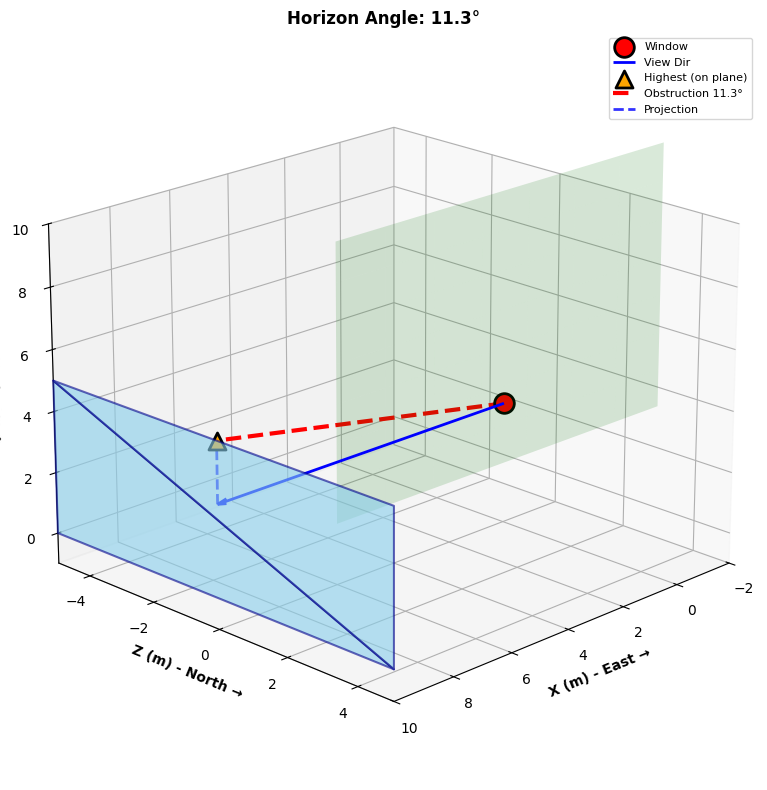

In [9]:
if result.get("status") == "success":
    data = result["data"]
    obstruction_degrees = data["obstruction_angle_degrees"]
    obstruction_radians = data["obstruction_angle_radians"]
    highest_point = data["highest_point"]
    
    # Create visualizer using new direction_angle format
    visualizer = HorizonAngleVisualizer(
        window_center=window_center,
        direction_angle=direction_angle,
        mesh_vertices=mesh,
        building_dimensions=(building_dist, building_height, building_width)
    )
    
    # Create figure and visualize
    fig = plt.figure(figsize=(14, 8))
    ax = fig.add_subplot(111, projection='3d')
    visualizer.visualize(ax, highest_point, obstruction_degrees)
    plt.tight_layout()
    plt.show()

### 👉 Zenith Angle Calculation

In [10]:
# Test zenith angle with the same building
response = requests.post(f"{SERVER_URL}/zenith_angle", json=request_data)
zenith_result = response.json()
print("Zenith Result:", zenith_result)

if zenith_result.get("status") == "success":
    data = zenith_result["data"]
    zenith_degrees = data["obstruction_angle_degrees"]
    zenith_radians = data["obstruction_angle_radians"]
    

Zenith Result: {'data': {'highest_point': None, 'obstruction_angle_degrees': 0.0, 'obstruction_angle_radians': 0.0, 'projected_point_count': 6}, 'status': 'success'}


### 👉 Overhead Obstruction Example

In [11]:
# Create horizontal overhead scenario
overhead_scenario = StandardScenarios.horizontal_overhead(
    window_height=3.0,
    roof_start=1.0,
    roof_end=5.0,
    roof_height=4.0,
    roof_width=14.0
)

overhead_request = overhead_scenario.to_request_data()
overhead_request["direction_angle"] = 0.2
# Calculate zenith angle
response = requests.post(f"{SERVER_URL}/zenith_angle", json=overhead_request)
overhead_result = response.json()

if overhead_result.get("status") == "success":
    data = overhead_result["data"]
    zenith_deg = data["obstruction_angle_degrees"]
    lowest_pt = data["highest_point"]
    
    print(f"Zenith Angle: {zenith_deg:.2f}°")
    if zenith_deg > 0:
        print(f"Furthest overhead point: ({lowest_pt['x']:.1f}, {lowest_pt['y']:.1f}, {lowest_pt['z']:.1f})")
    else:
        print("No overhead obstruction found on direction plane")
else:
    print("ERROR:", overhead_result.get("error"))

Zenith Angle: 80.97°
Furthest overhead point: (5.0, 7.0, 4.0)


In [12]:
overhead_scenario.meshes

[[[1.0, -7.0, 4.0],
  [1.0, 7.0, 4.0],
  [5.0, -7.0, 4.0],
  [1.0, 7.0, 4.0],
  [5.0, 7.0, 4.0],
  [5.0, -7.0, 4.0]]]

OVERHEAD {'x': 5.0, 'y': 7.0, 'z': 4.0}
LP3D [5. 7. 4.]
api  [5. 7. 4.]
overhead  [5. 0. 4.]
overhead converted [5. 0. 4.]
window pos  [0. 0. 3.]
ovhd pnt  [5. 0. 4.]
window pos  [0. 0. 3.]
hr pnt  [5. 0. 3.]


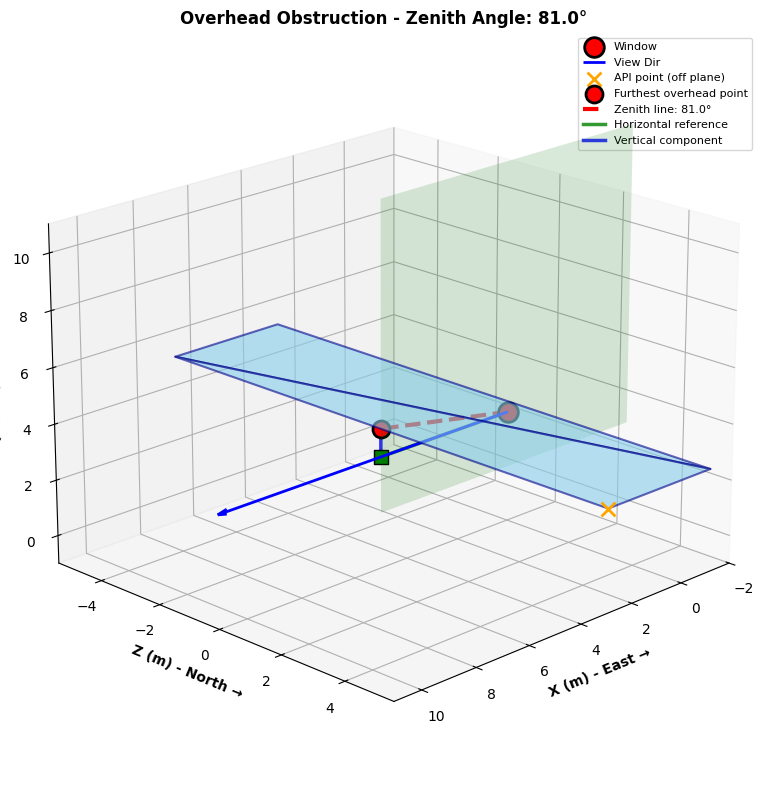

In [13]:
visualizer = ZenithAngleVisualizer(
    window_center=overhead_scenario.window_center,
    direction_angle=overhead_scenario.direction_angle,
    mesh_vertices=overhead_scenario.get_combined_mesh(),
    scene_dimensions=(8.0, 7.0, 4.0)
)

# Create figure and visualize
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')
visualizer.visualize(ax, lowest_pt, zenith_deg)
plt.tight_layout()
plt.show()

### 👉 Obstruction (Both Angles)

Use the `/obstruction` endpoint to calculate both horizon and zenith angles in a single request.

In [14]:
# Create mixed scenario with both vertical and horizontal obstructions
mixed_scenario = StandardScenarios.mixed_obstruction(window_height=3.0)

# Get obstruction angles for both
response = requests.post(f"{SERVER_URL}/obstruction", json=mixed_scenario.to_request_data())
both_result = response.json()

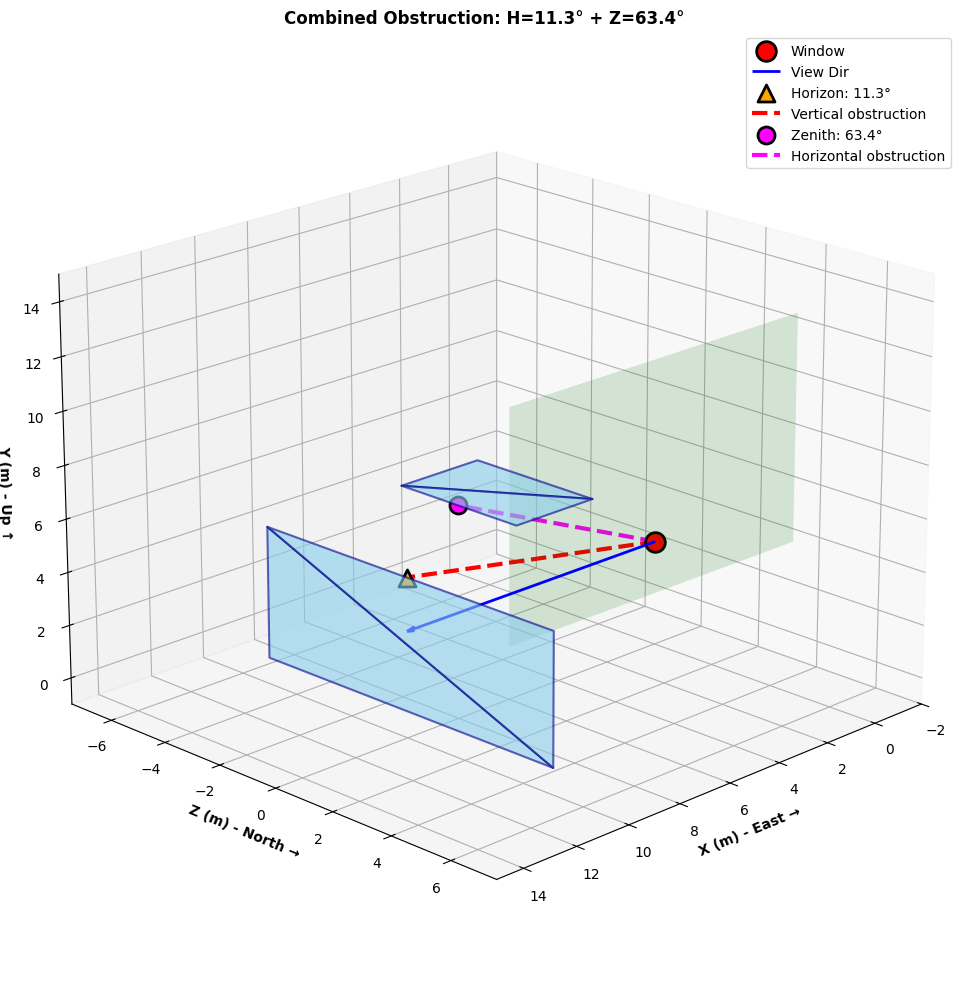

In [15]:
if both_result.get("status") == "success":
    # Extract data
    horizon_data = both_result["data"]["horizon"]
    zenith_data = both_result["data"]["zenith"]
    
    # Create combined visualizer using new direction_angle format
    visualizer = CombinedObstructionVisualizer(
        window_center=mixed_scenario.window_center,
        direction_angle=mixed_scenario.direction_angle,
        mesh_vertices=mixed_scenario.get_combined_mesh()
    )
    
    # Create figure and visualize
    fig = plt.figure(figsize=(16, 10))
    ax = fig.add_subplot(111, projection='3d')
    visualizer.visualize(ax, horizon_data, zenith_data)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping visualization - obstruction calculation failed")

### 👉 Real-World Data Example

Load and process a real window obstruction scenario from saved data.

In [25]:
# Import coordinate converter
import sys
if '.' not in sys.path:
    sys.path.insert(0, '.')

import coordinate_converter
importlib.reload(coordinate_converter)
from coordinate_converter import CoordinateConverter, convert_xzy_to_xyz, analyze_coordinates

import json

# Load real-world window data
sample_file = "window_4952361_request.json"
sample_path = f"../assets/sample1/{sample_file}"

with open(sample_path, 'r') as f:
    real_data = json.load(f)

print(f"Loaded: {sample_file}")
print(f"\n🔍 Original data (potentially XZY format):")
print(f"Window position: ({real_data['x']:.2f}, {real_data['y']:.2f}, {real_data['z']:.2f})")
real_data["direction_angle"] = 3.14
print(f"Mesh vertices: {len(real_data['mesh'])}")

# Analyze coordinate system
print(f"\n" + "="*60)
analyze_coordinates(real_data)
print("="*60)

# Convert to XYZ
corrected_data = convert_xzy_to_xyz(real_data)

print(f"\n✅ Converted data (XYZ format):")
print(f"Window position: ({corrected_data['x']:.2f}, {corrected_data['y']:.2f}, {corrected_data['z']:.2f})")
print(f"Mesh sample (first vertex):")
print(f"   Original: {real_data['mesh'][0]}")
print(f"   Converted: {corrected_data['mesh'][0]}")

Loaded: window_4952361_request.json

🔍 Original data (potentially XZY format):
Window position: (39.74, 46.07, 17.95)
Mesh vertices: 117018

📊 Coordinate System Analysis:
   Window position: (39.74, 46.07, 17.95)

   Coordinate ranges:
   coord_0: [-22.12, 180.74] (range: 202.86)
   coord_1: [-20.00, 33.43] (range: 53.43)
   coord_2: [-3.51, 127.13] (range: 130.65)

   Coord 1 range: 53.43
   Coord 2 range: 130.65

   ✅ Data appears to be in correct XYZ format

✅ Converted data (XYZ format):
Window position: (39.74, 17.95, 46.07)
Mesh sample (first vertex):
   Original: [87.84827523420441, 5.399999999999942, 108.74902371092104]
   Converted: [87.84827523420441, 108.74902371092104, 5.399999999999942]


In [27]:
# Test with corrected XYZ coordinates
print("🔬 Testing with corrected XYZ coordinates:")
print("="*60)

# Send corrected data to API
response = requests.post(f"{SERVER_URL}/obstruction", json=corrected_data)
corrected_result = response.json()

# Compare with original
# response_original = requests.post(f"{SERVER_URL}/obstruction", json=real_data)
# original_result = response_original.json()

if corrected_result.get("status") == "success":
    horizon_data = corrected_result["data"]["horizon"]
    zenith_data = corrected_result["data"]["zenith"]
    
    print(f"\n📊 Results with CORRECTED coordinates (XYZ):")
    print(f"   Horizon Angle: {horizon_data['obstruction_angle_degrees']:.2f}°")
    if horizon_data['highest_point']:
        hp = horizon_data['highest_point']
        print(f"   Highest point: ({hp['x']:.2f}, {hp['y']:.2f}, {hp['z']:.2f})")
    
    print(f"\n   Zenith Angle: {zenith_data['obstruction_angle_degrees']:.2f}°")
    if zenith_data['highest_point']:
        zp = zenith_data['highest_point']
        print(f"   Furthest overhead: ({zp['x']:.2f}, {zp['y']:.2f}, {zp['z']:.2f})")


print("="*60)

🔬 Testing with corrected XYZ coordinates:

📊 Results with CORRECTED coordinates (XYZ):
   Horizon Angle: 0.00°

   Zenith Angle: 0.00°


In [22]:
corrected_result

{'data': {'horizon': {'highest_point': None,
   'obstruction_angle_degrees': 0.0,
   'obstruction_angle_radians': 0.0,
   'projected_point_count': 20076},
  'zenith': {'highest_point': None,
   'obstruction_angle_degrees': 0.0,
   'obstruction_angle_radians': 0.0,
   'projected_point_count': 20076}},
 'status': 'success'}

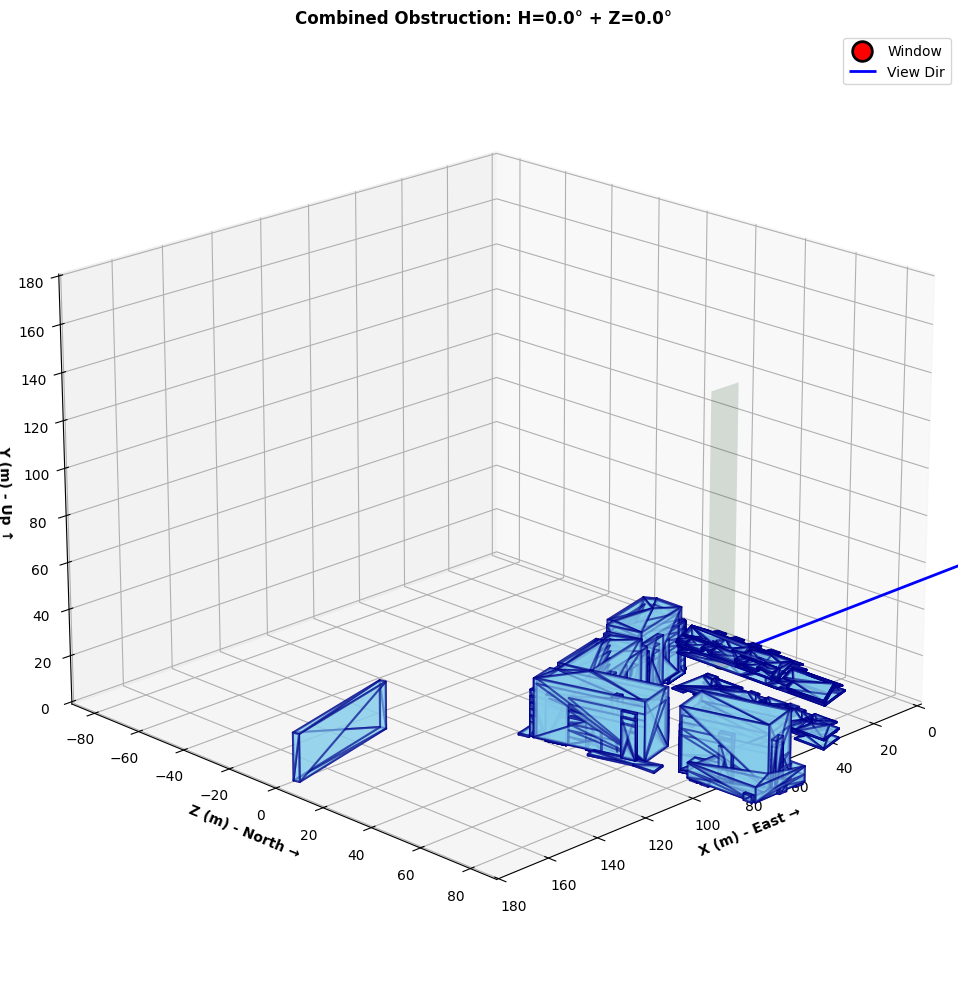

In [24]:
# # Visualize real-world obstruction data
# if corrected_result.get("status") == "success" and (horizon_data['obstruction_angle_degrees'] > 0 or zenith_data['obstruction_angle_degrees'] > 0):
# Create combined visualizer using new direction_angle format
visualizer = CombinedObstructionVisualizer(
    window_center=[corrected_data['x'], corrected_data['z'], corrected_data['y']],
    direction_angle=corrected_data['direction_angle'],
    mesh_vertices=corrected_data['mesh']
)

# Create figure and visualize
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')
visualizer.visualize(ax, horizon_data, zenith_data)
plt.tight_layout()
plt.show()
# else:
#     print("Skipping visualization - no obstruction found or calculation failed")

In [44]:
# Visualize real-world obstruction data
if corrected_result.get("status") == "success" and (horizon_data['obstruction_angle_degrees'] > 0 or zenith_data['obstruction_angle_degrees'] > 0):
    # Create combined visualizer using new direction_angle format
    visualizer = CombinedObstructionVisualizer(
        window_center=[corrected_data['x'], corrected_data['y'], corrected_data['z']],
        direction_angle=corrected_data['direction_angle'],
        mesh_vertices=corrected_data['mesh']
    )
    
    # Create figure and visualize
    fig = plt.figure(figsize=(16, 10))
    ax = fig.add_subplot(111, projection='3d')
    visualizer.visualize(ax, horizon_data, zenith_data)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping visualization - no obstruction found or calculation failed")

Skipping visualization - no obstruction found or calculation failed


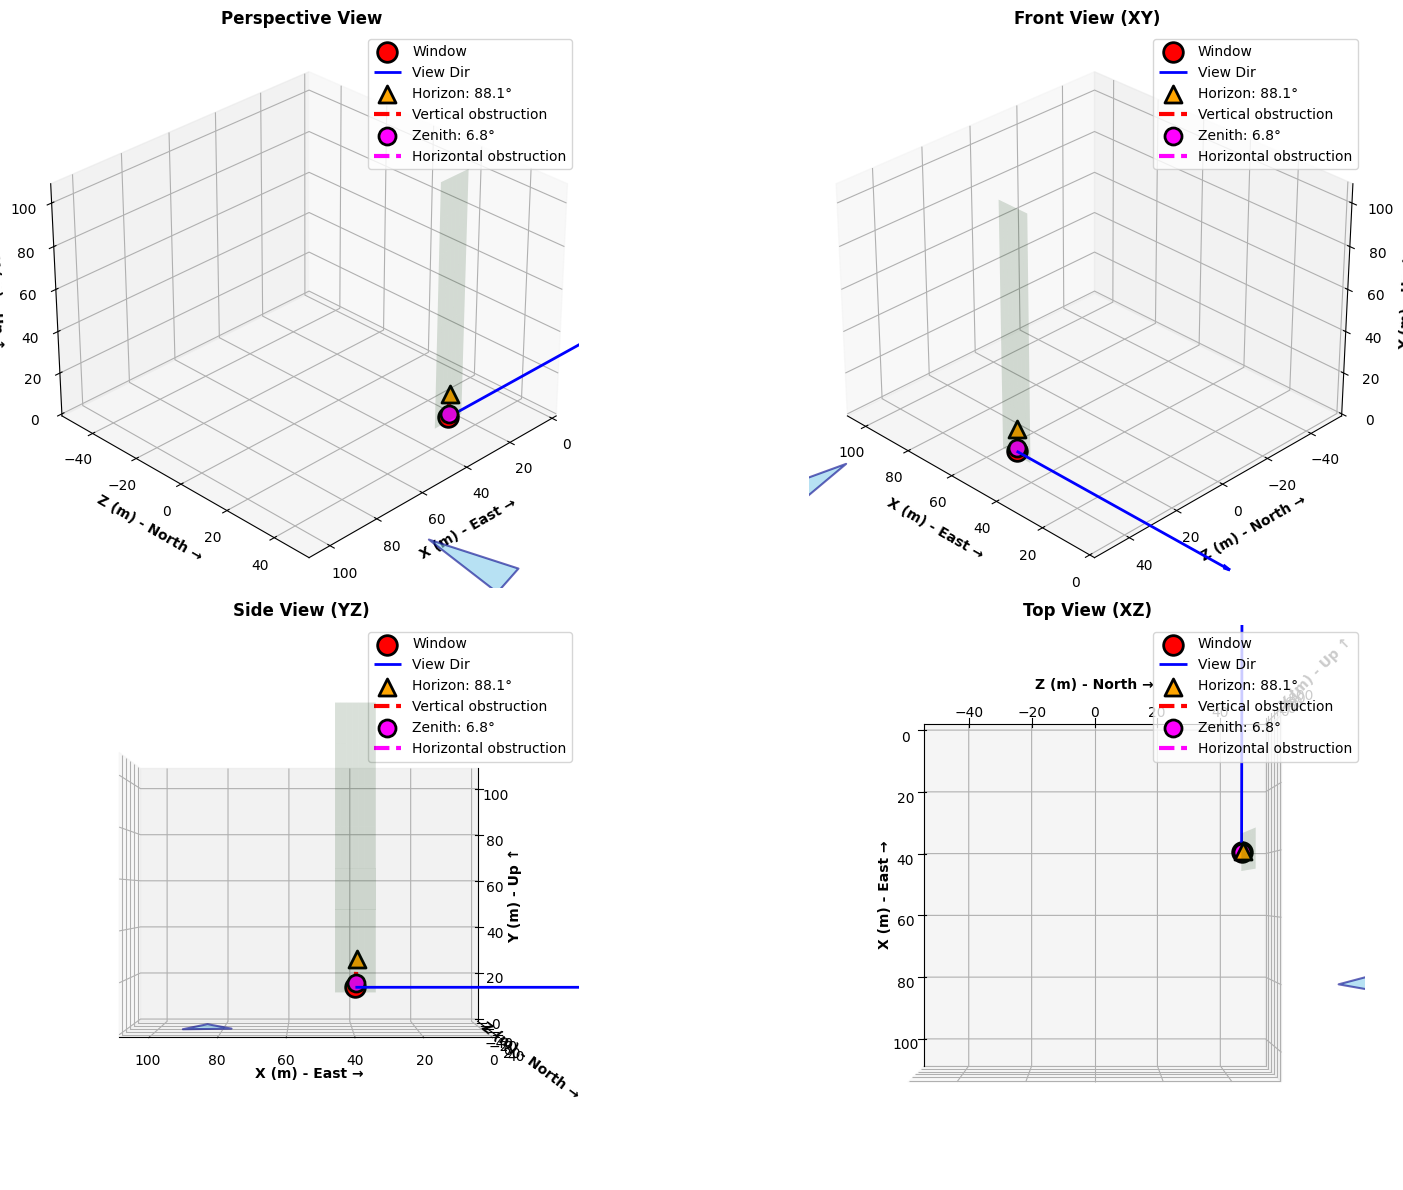

In [ ]:
h_data = corrected_result["data"]["horizon"]
z_data = corrected_result["data"]["zenith"]
fig = plt.figure(figsize=(18, 12))
    
# Define different viewing angles (elevation, azimuth)
views = [
    (30, 45, "Perspective View"),
    (30, 135, "Front View (XY)"),
    (0, 90, "Side View (YZ)"),
    (90, 0, "Top View (XZ)")
]

for idx, (elev, azim, title) in enumerate(views, 1):
    ax = fig.add_subplot(2, 2, idx, projection='3d')
    
    # Create visualizer for each subplot using direction_angle
    # Note: corrected_data['rad_y'] = 0.0, which is the direction_angle
    visualizer = CombinedObstructionVisualizer(
        window_center=[corrected_data['x'], corrected_data['y'], corrected_data['z']],
        direction_angle=corrected_data['direction_angle'],  # rad_y=0.0 (facing +X)
        mesh_vertices=corrected_data['mesh']
    )
    
    visualizer.visualize(ax, h_data, z_data)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 🐛 Debug: Window Direction Analysis

In [33]:
# Calculate and visualize the window's direction vector
calc = DirectionVectorCalculator()
direction = 3.14

print(f"Window Position: ({real_data['x']:.2f}, {real_data['y']:.2f}, {real_data['z']:.2f})")

# Analyze mesh bounds
mesh_array = np.array(real_data['mesh'])
print(f"\n📐 Mesh Bounds:")
print(f"  X: [{mesh_array[:, 0].min():.2f}, {mesh_array[:, 0].max():.2f}]")
print(f"  Y: [{mesh_array[:, 1].min():.2f}, {mesh_array[:, 1].max():.2f}]")
print(f"  Z: [{mesh_array[:, 2].min():.2f}, {mesh_array[:, 2].max():.2f}]")

# Check relative positions
print(f"\n🔍 Relative Position Check:")
print(f"  Window is at X={real_data['x']:.2f}")
print(f"  Mesh X range: [{mesh_array[:, 0].min():.2f}, {mesh_array[:, 0].max():.2f}]")
if real_data['x'] < mesh_array[:, 0].min():
    print(f"  ⚠️  Window is BEFORE the mesh (facing away from mesh)")
elif real_data['x'] > mesh_array[:, 0].max():
    print(f"  ✓ Window is AFTER the mesh (could be facing toward mesh)")

Window Position: (39.74, 17.95, 46.07)

📐 Mesh Bounds:
  X: [-22.12, 180.74]
  Y: [-20.00, 33.43]
  Z: [-3.51, 127.13]

🔍 Relative Position Check:
  Window is at X=39.74
  Mesh X range: [-22.12, 180.74]


TypeError: Value after * must be an iterable, not float

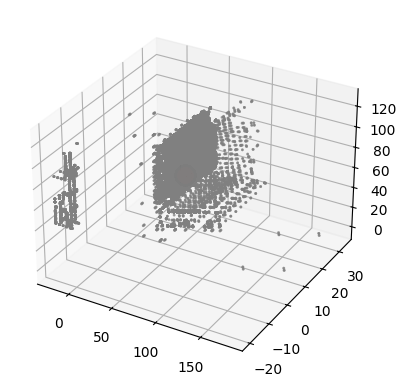

In [34]:
# Visualize direction vector and mesh positioning
fig = plt.figure(figsize=(16, 6))

# 3D view
ax1 = fig.add_subplot(131, projection='3d')
window_pos = np.array([real_data['x'], real_data['y'], real_data['z']])
mesh_vertices = np.array(real_data['mesh'])

# Plot mesh
ax1.scatter(mesh_vertices[:, 0], mesh_vertices[:, 1], mesh_vertices[:, 2], 
            c='gray', alpha=0.3, s=1, label='Mesh')
# Plot window
ax1.scatter(*window_pos, c='red', s=200, marker='o', label='Window', edgecolors='black', linewidths=2)
# Plot direction vector
direction_end = window_pos + direction * 20
ax1.quiver(*window_pos, *direction*20, color='blue', arrow_length_ratio=0.2, linewidth=3, label='Direction')

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.legend()
ax1.set_title('3D Scene Overview')

# Top view (XZ plane)
ax2 = fig.add_subplot(132)
ax2.scatter(mesh_vertices[:, 0], mesh_vertices[:, 2], c='gray', alpha=0.3, s=1, label='Mesh')
ax2.scatter(window_pos[0], window_pos[2], c='red', s=200, marker='o', label='Window', edgecolors='black', linewidths=2)
ax2.arrow(window_pos[0], window_pos[2], direction[0]*20, direction[2]*20, 
          head_width=2, head_length=1, fc='blue', ec='blue', linewidth=2, label='Direction')
ax2.set_xlabel('X')
ax2.set_ylabel('Z')
ax2.legend()
ax2.set_title('Top View (XZ)')
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

# Side view (XY plane)
ax3 = fig.add_subplot(133)
ax3.scatter(mesh_vertices[:, 0], mesh_vertices[:, 1], c='gray', alpha=0.3, s=1, label='Mesh')
ax3.scatter(window_pos[0], window_pos[1], c='red', s=200, marker='o', label='Window', edgecolors='black', linewidths=2)
ax3.arrow(window_pos[0], window_pos[1], direction[0]*20, direction[1]*20, 
          head_width=2, head_length=1, fc='blue', ec='blue', linewidth=2, label='Direction')
ax3.set_xlabel('X')
ax3.set_ylabel('Y (Height)')
ax3.legend()
ax3.set_title('Side View (XY)')
ax3.grid(True, alpha=0.3)
ax3.axis('equal')

plt.tight_layout()
plt.show()

### 🔧 Test with Corrected Window Direction

In [21]:
# Convert old angle system to new for real-world data
# Old: rad_y=π means facing -X direction  
# New: direction_angle=π means facing -X direction

print(f"📊 Converting real-world data to new angle system:")
print(f"   Old format: rad_x={real_data['rad_x']}, rad_y={real_data['rad_y']:.4f}")

# For horizontal-only viewing (rad_x=0), rad_y directly maps to direction_angle
if abs(real_data['rad_x']) < 0.01:  # Essentially horizontal
    new_direction_angle = real_data['rad_y']
    print(f"   New format: direction_angle={new_direction_angle:.4f}")
    print(f"   ✅ Direct conversion (horizontal viewing)")
else:
    print(f"   ⚠️  Old data has vertical tilt (rad_x={real_data['rad_x']:.4f})")
    print(f"   Converting to horizontal-only direction...")
    # Extract horizontal component
    calc = DirectionVectorCalculator()
    old_dir = calc.from_angles(real_data['rad_x'], real_data['rad_y'])
    horiz_dir = calc.get_horizontal_component(old_dir)
    # Calculate angle from horizontal direction
    new_direction_angle = np.arctan2(horiz_dir[2], horiz_dir[0])
    if new_direction_angle < 0:
        new_direction_angle += 2 * np.pi
    print(f"   New format: direction_angle={new_direction_angle:.4f}")

# Test with new format
new_format_data = {
    "x": real_data['x'],
    "y": real_data['y'],
    "z": real_data['z'],
    "direction_angle": 1.57,
    "mesh": real_data['mesh']
}

response_new = requests.post(f"{SERVER_URL}/obstruction", json=new_format_data)
new_result = response_new.json()

print(f"\n🔍 Comparison:")
print(f"   Old system: H={real_result['data']['horizon']['obstruction_angle_degrees']:.2f}°, Z={real_result['data']['zenith']['obstruction_angle_degrees']:.2f}°")
if new_result.get("status") == "success":
    print(f"   New system: H={new_result['data']['horizon']['obstruction_angle_degrees']:.2f}°, Z={new_result['data']['zenith']['obstruction_angle_degrees']:.2f}°")
else:
    print(f"   Error: {new_result.get('error')}")

📊 Converting real-world data to new angle system:
   Old format: rad_x=0, rad_y=3.1416
   New format: direction_angle=3.1416
   ✅ Direct conversion (horizontal viewing)

🔍 Comparison:
   Old system: H=88.29°, Z=9.84°
   New system: H=23.14°, Z=83.74°


In [36]:
# The window appears to be embedded in the mesh, looking backward
# Let's analyze what's in each direction

print("🔍 Analysis: Window is INSIDE the mesh volume")
print(f"   Window X position: {real_data['x']:.2f}")
print(f"   Mesh X bounds: [{mesh_array[:, 0].min():.2f}, {mesh_array[:, 0].max():.2f}]")
print(f"\n   Current direction (rad_y={real_data['rad_y']:.4f} ≈ π):")
print(f"   - Looking in -X direction (backward)")
print(f"   - Can see mesh from X={mesh_array[:, 0].min():.2f} to X={real_data['x']:.2f}")
print(f"   - This explains the 88.3° obstruction angle!")

# Let's test what happens if we flip the direction
corrected_data = real_data.copy()
corrected_data['rad_y'] = 0.0  # Face forward (+X direction)

response_corrected = requests.post(f"{SERVER_URL}/obstruction", json=corrected_data)
corrected_result = response_corrected.json()

print(f"\n✅ Testing with corrected direction (rad_y=0, facing +X):")
if corrected_result.get("status") == "success":
    h_data = corrected_result["data"]["horizon"]
    z_data = corrected_result["data"]["zenith"]
    print(f"   Horizon Angle: {h_data['obstruction_angle_degrees']:.2f}°")
    print(f"   Zenith Angle: {z_data['obstruction_angle_degrees']:.2f}°")
else:
    print(f"   Error: {corrected_result.get('error')}")

print(f"\n💡 Conclusion:")
print(f"   The original data has rad_y=π, meaning the window faces backward.")
print(f"   Since the window is embedded in the mesh, it sees geometry behind it.")

🔍 Analysis: Window is INSIDE the mesh volume
   Window X position: 39.74
   Mesh X bounds: [-22.12, 180.74]


KeyError: 'rad_y'

In [37]:
# Visualize from multiple viewing angles
if corrected_result.get("status") == "success" and (h_data['obstruction_angle_degrees'] > 0 or z_data['obstruction_angle_degrees'] > 0):
    fig = plt.figure(figsize=(18, 12))
    
    # Define different viewing angles (elevation, azimuth)
    views = [
        (30, 45, "Perspective View"),
        (30, 135, "Front View (XY)"),
        (0, 90, "Side View (YZ)"),
        (90, 0, "Top View (XZ)")
    ]
    
    for idx, (elev, azim, title) in enumerate(views, 1):
        ax = fig.add_subplot(2, 2, idx, projection='3d')
        
        # Create visualizer for each subplot using direction_angle
        # Note: corrected_data['rad_y'] = 0.0, which is the direction_angle
        visualizer = CombinedObstructionVisualizer(
            window_center=[corrected_data['x'], corrected_data['y'], corrected_data['z']],
            direction_angle=corrected_data['rad_y'],  # rad_y=0.0 (facing +X)
            mesh_vertices=corrected_data['mesh']
        )
        
        visualizer.visualize(ax, h_data, z_data)
        ax.view_init(elev=elev, azim=azim)
        ax.set_title(title, fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping multi-angle visualization - no obstruction found or calculation failed")

NameError: name 'h_data' is not defined

### 💾 Export Mesh to OBJ File

Export the mesh data to a Wavefront OBJ file for use in 3D modeling software (Blender, Maya, etc.)

In [13]:
# Export the real-world mesh to OBJ format
output_filename = f"../assets/exports/{sample_file.replace('.json', '.obj')}"

# Create exports directory if it doesn't exist
import os
os.makedirs("../assets/exports", exist_ok=True)

# Export mesh with window position in header
MeshExporter.to_obj(
    mesh_vertices=real_data['mesh'],
    output_path=output_filename,
    window_center=[real_data['x'], real_data['y'], real_data['z']]
)

print(f"✅ Exported mesh to: {output_filename}")
print(f"   Vertices: {len(real_data['mesh']):,}")
print(f"   Triangles: {len(real_data['mesh']) // 3:,}")
print(f"\nYou can now open this file in Blender, MeshLab, or any 3D viewer!")

✅ Exported mesh to: ../assets/exports/window_4952361_request.obj
   Vertices: 117,018
   Triangles: 39,006

You can now open this file in Blender, MeshLab, or any 3D viewer!
